In [1]:
from sob import TrainingConfig, Trainer
import matplotlib.pyplot as plt
from torchvision.io import decode_image

config = TrainingConfig.from_run("weights")
trainer = Trainer(config)

Kaolin not found, edge metrics will not be available


/home/aurlien/dev/SOB/src/sob/networks/hr_decoder.py:76: UserWarning: HRDepth requires 5 scales, but the provided backbone has only 4. The first scale will be duplicated and upsampled!
  warnings.warn(


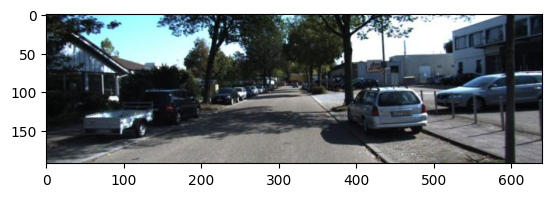

In [2]:
img = decode_image("sample.jpg") / 255.0
plt.imshow(img.permute(1, 2, 0).detach().cpu().numpy())
plt.show()


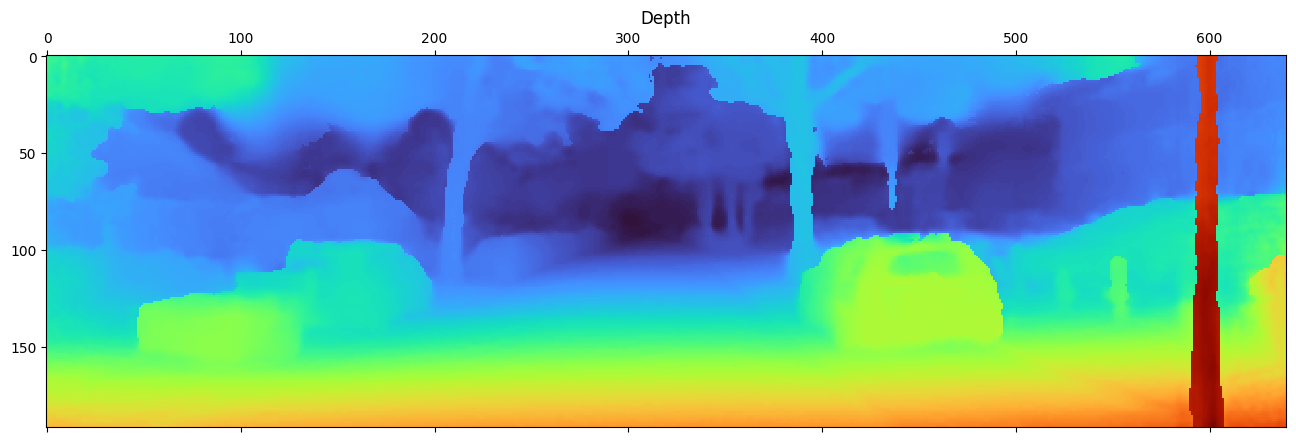

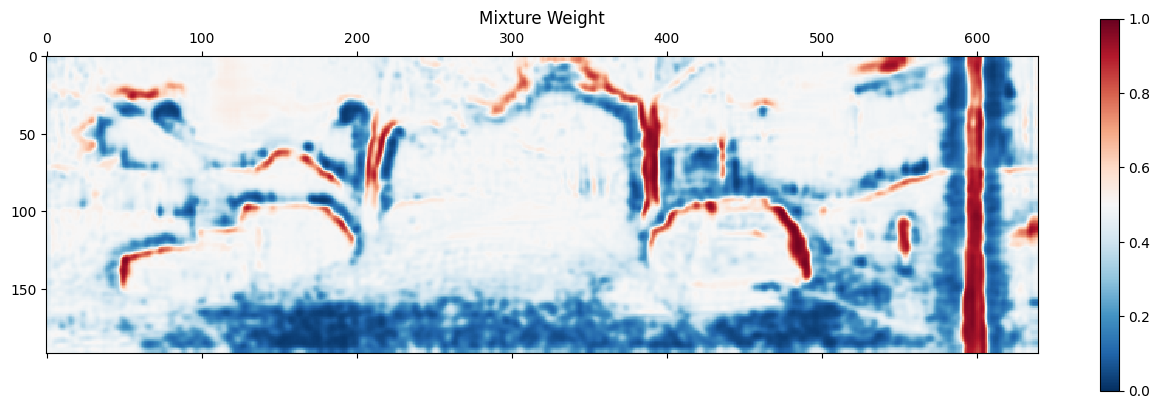

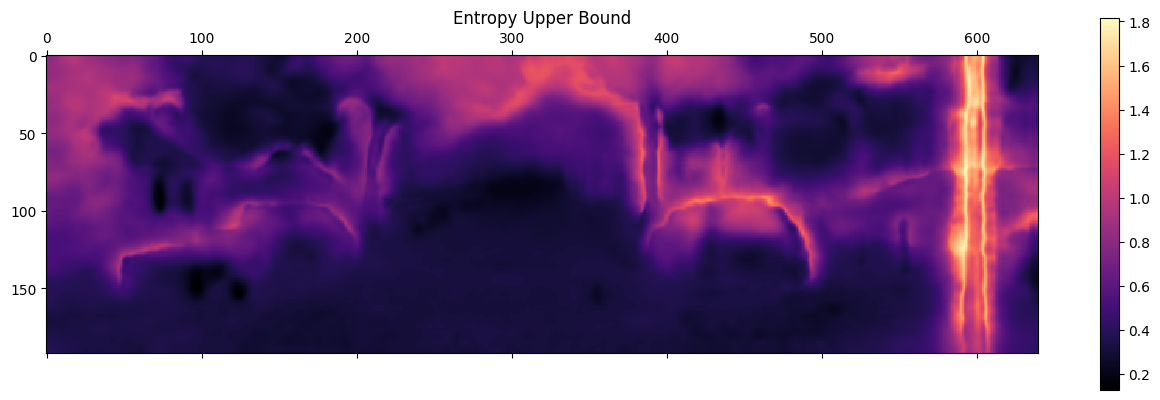

In [4]:
pred_dist = trainer.inference_step(img[None].cuda())

# unscaled inverse depth
plt.matshow(pred_dist.disp_mode_alpha().squeeze().detach().cpu().numpy(), cmap="turbo")
plt.title("Depth")

plt.matshow(pred_dist.alpha[:, 0].squeeze().detach().cpu().numpy(), cmap="RdBu_r", vmin=0, vmax=1)
plt.title("Mixture Weight")
plt.colorbar()

plt.matshow(pred_dist.entropy_upper_bound().cpu().squeeze(), cmap="magma")
plt.title("Entropy Upper Bound")
plt.colorbar()